In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_split_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_csv_5, metrics_csv_6, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)
    df5 = pd.read_csv(metrics_csv_5)
    df6 = pd.read_csv(metrics_csv_6)

    sns.set_theme(style="darkgrid")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 9), sharey=True)
    fig.subplots_adjust(wspace=0.05)
    fontsize = 14

    # Training Metrics
    ax1.plot(df1['Epoch'][:500], df1['Train BLSTM RMSE'][:500], label='BERT-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'][:500], df2['Train GCN RMSE'][:500], label='BERT-GCN Init.\nw/ BERT-MLM ESM INIT.', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'][:500], df3['Train RMSE'][:500], label='ESM-FCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'][:500], df4['Train RMSE'][:500], label='ESM-GCN', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1.plot(df5['Epoch'][:500], df5['Train RMSE'][:500], label='ESM-BLSTM', color='tab:purple', linestyle='-', linewidth=1.5)
    ax1.plot(df6['Epoch'][:500], df6['Train RMSE'][:500], label='ESM-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:brown', linestyle='-', linewidth=1.5)

    ax2.plot(df1['Epoch'][500:], df1['Train BLSTM RMSE'][500:], label='BERT-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'][500:], df2['Train GCN RMSE'][500:], label='BERT-GCN Init.\nw/ BERT-MLM ESM INIT.', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'][500:], df3['Train RMSE'][500:], label='ESM-FCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'][500:], df4['Train RMSE'][500:], label='ESM-GCN', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2.plot(df5['Epoch'][500:], df5['Train RMSE'][500:], label='ESM-BLSTM', color='tab:purple', linestyle='-', linewidth=1.5)
    ax2.plot(df6['Epoch'][500:], df6['Train RMSE'][500:], label='ESM-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:brown', linestyle='-', linewidth=1.5)

    # Testing Metrics
    ax3.plot(df1['Epoch'][:500], df1['Test BLSTM RMSE'][:500], label='BERT-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:blue', linestyle='-', linewidth=1.5)
    ax3.plot(df2['Epoch'][:500], df2['Test GCN RMSE'][:500], label='BERT-GCN Init.\nw/ BERT-MLM ESM INIT.', color='tab:green', linestyle='-', linewidth=1.5)
    ax3.plot(df3['Epoch'][:500], df3['Test RMSE'][:500], label='ESM-FCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax3.plot(df4['Epoch'][:500], df4['Test RMSE'][:500], label='ESM-GCN', color='tab:orange', linestyle='-', linewidth=1.5)
    ax3.plot(df5['Epoch'][:500], df5['Test RMSE'][:500], label='ESM-BLSTM', color='tab:purple', linestyle='-', linewidth=1.5)
    ax3.plot(df6['Epoch'][:500], df6['Test RMSE'][:500], label='ESM-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:brown', linestyle='-', linewidth=1.5)

    ax4.plot(df1['Epoch'][500:], df1['Test BLSTM RMSE'][500:], label='BERT-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:blue', linestyle='-', linewidth=1.5)
    ax4.plot(df2['Epoch'][500:], df2['Test GCN RMSE'][500:], label='BERT-GCN Init.\nw/ BERT-MLM ESM INIT.', color='tab:green', linestyle='-', linewidth=1.5)
    ax4.plot(df3['Epoch'][500:], df3['Test RMSE'][500:], label='ESM-FCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax4.plot(df4['Epoch'][500:], df4['Test RMSE'][500:], label='ESM-GCN', color='tab:orange', linestyle='-', linewidth=1.5)
    ax4.plot(df5['Epoch'][500:], df5['Test RMSE'][500:], label='ESM-BLSTM', color='tab:purple', linestyle='-', linewidth=1.5)
    ax4.plot(df6['Epoch'][500:], df6['Test RMSE'][500:], label='ESM-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:brown', linestyle='-', linewidth=1.5)

    # Customize axes
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(-0.1, 3)
        ax.tick_params(axis='both', labelsize=fontsize)

    ax1.set_xlim(-50, 500)
    ax2.set_xlim(500, 1050)
    ax3.set_xlim(-50, 500)
    ax4.set_xlim(500, 1050)

    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_xlabel('Epochs', fontsize=fontsize, x=1.02)

    # Add legend subplot
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax4.legend(loc='upper right', fontsize=fontsize-5, frameon=False)

    ax2.set_title('Training', loc='right', fontsize=fontsize)
    ax4.set_title('Testing', loc='right', fontsize=fontsize)

    # Add the slanted lines for axis split
    d = .5
    kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=10,
                linestyle="none", color='k', mec='k', mew=1.25, clip_on=False, zorder=5)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
    ax3.plot([1, 1], [0, 1], transform=ax3.transAxes, **kwargs)
    ax4.plot([0, 0], [0, 1], transform=ax4.transAxes, **kwargs)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test GCN RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    best_df5_rmse = find_best_epoch(metrics_csv_5, 'Test RMSE')
    best_df6_rmse = find_best_epoch(metrics_csv_6, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"BERT-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"BERT-GCN Init. w/ BERT-MLM ESM INIT.: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ESM-FCN: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"ESM-GCN: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")
    print(f"ESM-BLSTM: epoch {best_df5_rmse[0]}, rmse {best_df5_rmse[1]:.4f}")
    print(f"ESM-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch {best_df6_rmse[0]}, rmse {best_df6_rmse[1]:.4f}")

    ax3.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['BERT-BLSTM Init. w/ BERT-MLM ESM INIT.']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['BERT-GCN Init. w/ BERT-MLM ESM INIT.']), ha='center', va='top', color='tab:green', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(coords['ESM-FCN']), ha='center', va='top', color='tab:red', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(coords['ESM-GCN']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df5_rmse[0]}, {best_df5_rmse[1]:.4f})', best_df5_rmse, 
        textcoords="offset points", xytext=(coords['ESM-BLSTM']), ha='center', va='top', color='tab:purple', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:purple', lw=1, alpha=0.6)
    )
    ax3.annotate(
        f'({best_df6_rmse[0]}, {best_df6_rmse[1]:.4f})', best_df6_rmse, 
        textcoords="offset points", xytext=(coords['ESM-BLSTM Init. w/ BERT-MLM ESM INIT.']), ha='center', va='top', color='tab:brown', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:brown', lw=1, alpha=0.6)
    )

    plt.tight_layout(w_pad=-0.2)
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_csv_5, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)
    df5 = pd.read_csv(metrics_csv_5)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 14

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train BLSTM RMSE'], label='BERT-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'], df4['Train RMSE'], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1.plot(df5['Epoch'], df5['Train RMSE'], label='ESM-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:purple', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1.set_title('Training', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test BLSTM RMSE'], label='BERT-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='ESM-FCN', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='ESM-GCN', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'], df4['Test RMSE'], label='ESM-BLSTM', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2.plot(df5['Epoch'], df5['Test RMSE'], label='ESM-BLSTM Init.\nw/ BERT-MLM ESM INIT.', color='tab:purple', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2.set_title('Testing', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test BLSTM RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    best_df5_rmse = find_best_epoch(metrics_csv_5, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"BERT-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"ESM-FCN: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"ESM-GCN: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"ESM-BLSTM: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")
    print(f"ESM-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch {best_df5_rmse[0]}, rmse {best_df5_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['BERT-BLSTM Init. w/ BERT-MLM ESM INIT.']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['ESM-FCN']), ha='center', va='top', color='tab:green', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(coords['ESM-GCN']), ha='center', va='top', color='tab:red', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(coords['ESM-BLSTM']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df5_rmse[0]}, {best_df5_rmse[1]:.4f})', best_df5_rmse, 
        textcoords="offset points", xytext=(coords['ESM-BLSTM Init. w/ BERT-MLM ESM INIT.']), ha='center', va='top', color='tab:purple', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:purple', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_split_preembedded_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, metrics_csv_5, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)
    df5 = pd.read_csv(metrics_csv_5)

    sns.set_theme(style="darkgrid")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 9), sharey=True)
    fig.subplots_adjust(wspace=0.05)
    fontsize = 14

    # Training Metrics
    ax1.plot(df1['Epoch'][:500], df1['Train RMSE'][:500], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'][:500], df2['Train RMSE'][:500], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'][:500], df3['Train RMSE'][:500], label='BLSTM NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'][:500], df4['Train RMSE'][:500], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1.plot(df5['Epoch'][:500], df5['Train RMSE'][:500], label='GCN NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:purple', linestyle='-', linewidth=1.5)

    ax2.plot(df1['Epoch'][500:], df1['Train RMSE'][500:], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'][500:], df2['Train RMSE'][500:], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'][500:], df3['Train RMSE'][500:], label='BLSTM NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'][500:], df4['Train RMSE'][500:], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2.plot(df5['Epoch'][500:], df5['Train RMSE'][:500:], label='GCN NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:purple', linestyle='-', linewidth=1.5)

    # Testing Metrics
    ax3.plot(df1['Epoch'][:500], df1['Test RMSE'][:500], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax3.plot(df2['Epoch'][:500], df2['Test RMSE'][:500], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax3.plot(df3['Epoch'][:500], df3['Test RMSE'][:500], label='BLSTM NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:red', linestyle='-', linewidth=1.5)
    ax3.plot(df4['Epoch'][:500], df4['Test RMSE'][:500], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)
    ax3.plot(df5['Epoch'][:500], df5['Train RMSE'][:500], label='GCN NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:purple', linestyle='-', linewidth=1.5)

    ax4.plot(df1['Epoch'][500:], df1['Test RMSE'][500:], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax4.plot(df2['Epoch'][500:], df2['Test RMSE'][500:], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax4.plot(df3['Epoch'][500:], df3['Test RMSE'][500:], label='BLSTM NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:red', linestyle='-', linewidth=1.5)
    ax4.plot(df4['Epoch'][500:], df4['Test RMSE'][500:], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)
    ax4.plot(df5['Epoch'][500:], df5['Train RMSE'][500:], label='GCN NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:purple', linestyle='-', linewidth=1.5)

    # Customize axes
    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_ylim(-0.1, 3)
        ax.tick_params(axis='both', labelsize=fontsize)

    ax1.set_xlim(-50, 500)
    ax2.set_xlim(500, 1050)
    ax3.set_xlim(-50, 500)
    ax4.set_xlim(500, 1050)

    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_ylabel('RMSE', fontsize=fontsize)
    ax3.set_xlabel('Epochs', fontsize=fontsize, x=1.02)
    
    # Add legend subplot
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax4.legend(loc='upper right', fontsize=fontsize-5, frameon=False)

    ax2.set_title('Training', loc='right', fontsize=fontsize)
    ax4.set_title('Testing', loc='right', fontsize=fontsize)

    # Add the slanted lines for axis split
    d = .5
    kwargs = dict(marker=[(-d, -1), (d, 1)], markersize=10,
                linestyle="none", color='k', mec='k', mew=1.25, clip_on=False, zorder=5)
    ax1.plot([1, 1], [0, 1], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 0], [0, 1], transform=ax2.transAxes, **kwargs)
    ax3.plot([1, 1], [0, 1], transform=ax3.transAxes, **kwargs)
    ax4.plot([0, 0], [0, 1], transform=ax4.transAxes, **kwargs)
    
    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    best_df5_rmse = find_best_epoch(metrics_csv_5, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"FCN ESM-CLS Preembedded: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"BLSTM ESM-AA Preembedded: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"GCN ESM-AA Preembedded: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")
    print(f"GCN NLP Preembedded Init. w/ BERT-MLM ESM INIT.: epoch {best_df5_rmse[0]}, rmse {best_df5_rmse[1]:.4f}")

    ax4.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['FCN ESM-CLS Preembedded']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['BLSTM ESM-AA Preembedded']), ha='center', va='top', color='tab:green', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(coords['BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.T']), ha='center', va='top', color='tab:red', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(coords['GCN ESM-AA Preembedded']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax4.annotate(
        f'({best_df5_rmse[0]}, {best_df5_rmse[1]:.4f})', best_df5_rmse, 
        textcoords="offset points", xytext=(coords['GCN NLP Preembedded Init. w/ BERT-MLM ESM INIT.T']), ha='center', va='top', color='tab:purple', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:purple', lw=1, alpha=0.6)
    )

    plt.tight_layout(w_pad=-0.2)
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_preembedded_log_file(metrics_csv_1, metrics_csv_2, metrics_csv_3, metrics_csv_4, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)
    df3 = pd.read_csv(metrics_csv_3)
    df4 = pd.read_csv(metrics_csv_4)

    sns.set_theme(style="darkgrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))  # 2 rows, 1 column
    fontsize = 14

    # Plot 1: Training Metrics (binding, expression)
    ax1.plot(df1['Epoch'], df1['Train RMSE'], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1.plot(df2['Epoch'], df2['Train RMSE'], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax1.plot(df3['Epoch'], df3['Train RMSE'], label='BLSTM NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:red', linestyle='-', linewidth=1.5)
    ax1.plot(df4['Epoch'], df4['Train RMSE'], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1.tick_params(axis='x', labelsize=fontsize)    
    ax1.set_xlim(-50, 1050)
    ax1.set_ylabel('RMSE', fontsize=fontsize)
    ax1.tick_params(axis='y', labelsize=fontsize)
    ax1.set_ylim(-0.1, 2.5)
    ax1.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1.set_title('Training', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (binding, expression)
    ax2.plot(df1['Epoch'], df1['Test RMSE'], label='FCN ESM-CLS Preembedded', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2.plot(df2['Epoch'], df2['Test RMSE'], label='BLSTM ESM-AA Preembedded', color='tab:green', linestyle='-', linewidth=1.5)
    ax2.plot(df3['Epoch'], df3['Test RMSE'], label='BLSTM NLP Preembedded Init.\nw/ BERT-MLM ESM INIT.', color='tab:red', linestyle='-', linewidth=1.5)
    ax2.plot(df4['Epoch'], df4['Test RMSE'], label='GCN ESM-AA Preembedded', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2.set_xlabel('Epochs', fontsize=fontsize)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.set_xlim(-50, 1050)
    ax2.set_ylabel('RMSE', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)
    ax2.set_ylim(-0.1, 2.5)
    ax2.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2.set_title('Testing', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1_rmse = find_best_epoch(metrics_csv_1, 'Test RMSE')
    best_df2_rmse = find_best_epoch(metrics_csv_2, 'Test RMSE')
    best_df3_rmse = find_best_epoch(metrics_csv_3, 'Test RMSE')
    best_df4_rmse = find_best_epoch(metrics_csv_4, 'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"FCN ESM-CLS Preembedded: epoch {best_df1_rmse[0]}, rmse {best_df1_rmse[1]:.4f}")
    print(f"BLSTM ESM-AA Preembedded: epoch {best_df2_rmse[0]}, rmse {best_df2_rmse[1]:.4f}")
    print(f"BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.T: epoch {best_df3_rmse[0]}, rmse {best_df3_rmse[1]:.4f}")
    print(f"GCN ESM-AA Preembedded: epoch {best_df4_rmse[0]}, rmse {best_df4_rmse[1]:.4f}")

    ax2.annotate(
        f'({best_df1_rmse[0]}, {best_df1_rmse[1]:.4f})', best_df1_rmse, 
        textcoords="offset points", xytext=(coords['FCN ESM-CLS Preembedded']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df2_rmse[0]}, {best_df2_rmse[1]:.4f})', best_df2_rmse, 
        textcoords="offset points", xytext=(coords['BLSTM ESM-AA Preembedded']), ha='center', va='top', color='tab:green', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:green', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df3_rmse[0]}, {best_df3_rmse[1]:.4f})', best_df3_rmse, 
        textcoords="offset points", xytext=(coords['BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.T']), ha='center', va='top', color='tab:red', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:red', lw=1, alpha=0.6)
    )
    ax2.annotate(
        f'({best_df4_rmse[0]}, {best_df4_rmse[1]:.4f})', best_df4_rmse, 
        textcoords="offset points", xytext=(coords['GCN ESM-AA Preembedded']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

---
## Model Comparisons - Updating Embedding Models

Binding:
Best test RMSE at epoch x:
BERT-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch 407, rmse 1.0088
BERT-GCN Init. w/ BERT-MLM ESM INIT.: epoch 687, rmse 1.1326
ESM-FCN: epoch 965, rmse 0.5185
ESM-GCN: epoch 576, rmse 0.5347
ESM-BLSTM: epoch 329, rmse 0.5242
ESM-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch 119, rmse 0.5954

Expression:
Best test RMSE at epoch x:
BERT-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch 939, rmse 0.5604
BERT-GCN Init. w/ BERT-MLM ESM INIT.: epoch 995, rmse 0.6230
ESM-FCN: epoch 233, rmse 0.3145
ESM-GCN: epoch 974, rmse 0.3213
ESM-BLSTM: epoch 907, rmse 0.3202
ESM-BLSTM Init. w/ BERT-MLM ESM INIT.: epoch 211, rmse 0.3383


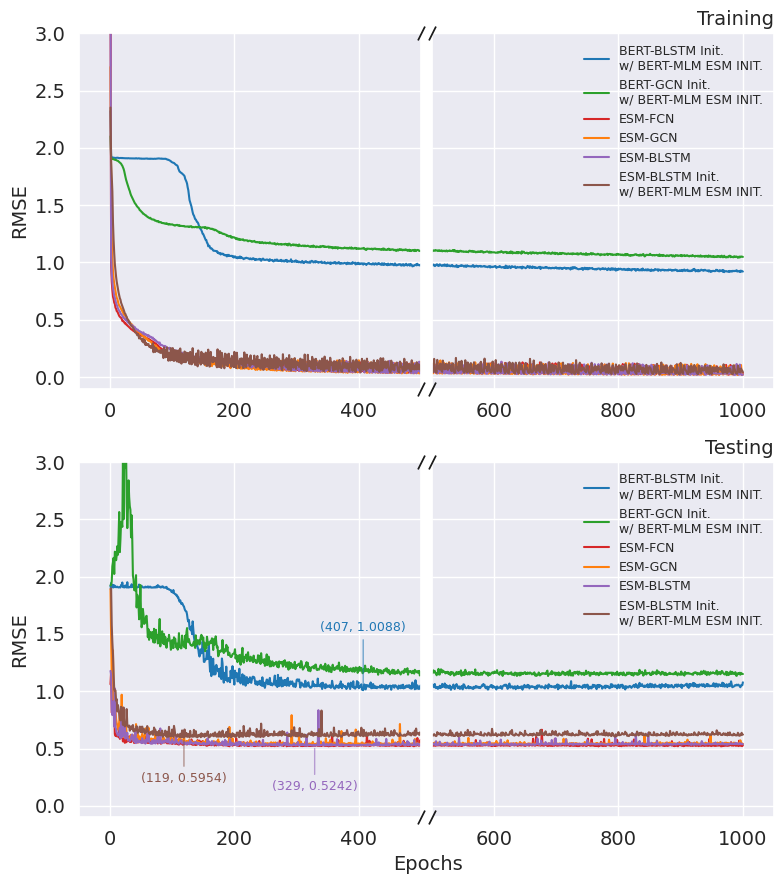

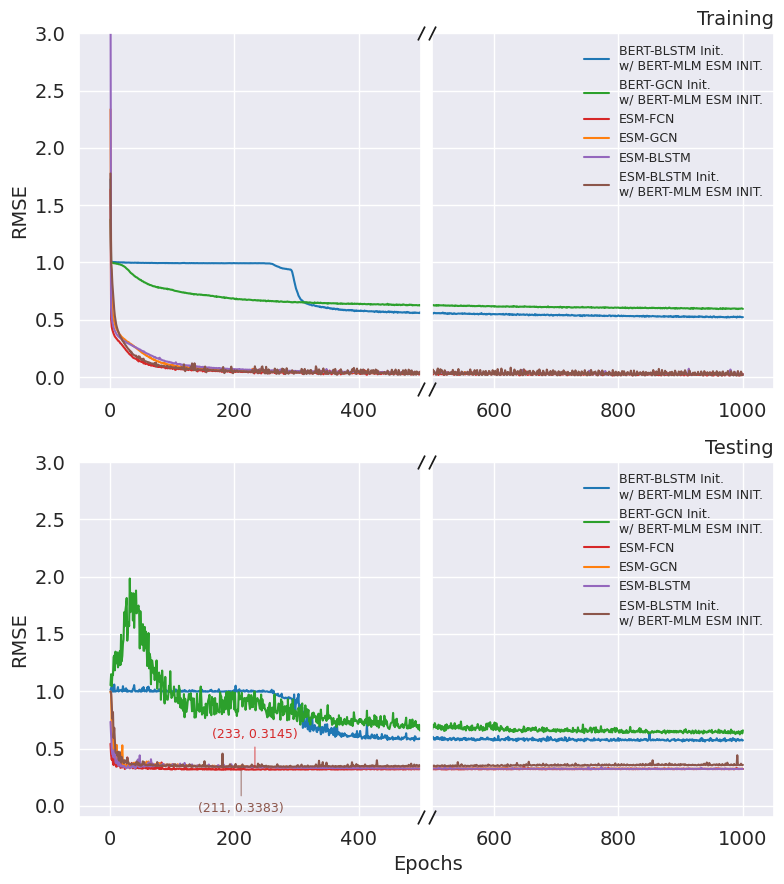

In [3]:
bert_blstm = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-binding-2024-12-07_02-56/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
bert_gcn = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-binding-2024-12-05_17-52/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_fcn = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_gcn = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2024-12-07_09-12/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_blstm = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-binding-2024-12-07_08-58/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
esm_blstm_bert_mlm_esm_init = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-12-07_09-28/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/binding"
coords = {
    "BERT-BLSTM Init. w/ BERT-MLM ESM INIT.": (0, 50),
    "BERT-GCN Init. w/ BERT-MLM ESM INIT.": (5, 50),
    "ESM-FCN": (0, -40),
    "ESM-GCN": (-15,-25),
    "ESM-BLSTM": (0,-25),
    "ESM-BLSTM Init. w/ BERT-MLM ESM INIT.": (0,-25)
}
print("Binding:")
plot_comparative_split_log_file(bert_blstm, bert_gcn, esm_fcn, esm_gcn, esm_blstm, esm_blstm_bert_mlm_esm_init, coords, f"{comparison_file}.model_comp_split.pdf")

bert_blstm = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-expression-2024-12-07_02-58/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
bert_gcn = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-expression-2024-12-05_17-51/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_fcn = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_gcn = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2024-12-07_09-13/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_blstm = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-expression-2024-12-07_09-00/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
esm_blstm_bert_mlm_esm_init = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-12-07_09-36/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/expression"
coords = {
    "BERT-BLSTM Init. w/ BERT-MLM ESM INIT.": (0, 50),
    "BERT-GCN Init. w/ BERT-MLM ESM INIT.": (5, 50),
    "ESM-FCN": (0, 30),
    "ESM-GCN": (0,-25),
    "ESM-BLSTM": (0,35),
    "ESM-BLSTM Init. w/ BERT-MLM ESM INIT.": (0,-25)
}
print("\nExpression:")
plot_comparative_split_log_file(bert_blstm, bert_gcn, esm_fcn, esm_gcn, esm_blstm, esm_blstm_bert_mlm_esm_init, coords, f"{comparison_file}.model_comp_split.pdf")

---
## Model Comparisons - Frozen Embedding (Preembedded) Models

Binding:
Best test RMSE at epoch x:
FCN ESM-CLS Preembedded: epoch 987, rmse 1.2238
BLSTM ESM-AA Preembedded: epoch 547, rmse 0.5518
BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.: epoch 999, rmse 1.1148
GCN ESM-AA Preembedded: epoch 997, rmse 1.0719
GCN NLP Preembedded Init. w/ BERT-MLM ESM INIT.: epoch 989, rmse 1.2092

Expression
Best test RMSE at epoch x:
FCN ESM-CLS Preembedded: epoch 1000, rmse 0.6107
BLSTM ESM-AA Preembedded: epoch 193, rmse 0.3335
BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.: epoch 986, rmse 0.5834
GCN ESM-AA Preembedded: epoch 993, rmse 0.5409
GCN NLP Preembedded Init. w/ BERT-MLM ESM INIT.: epoch 999, rmse 0.6670


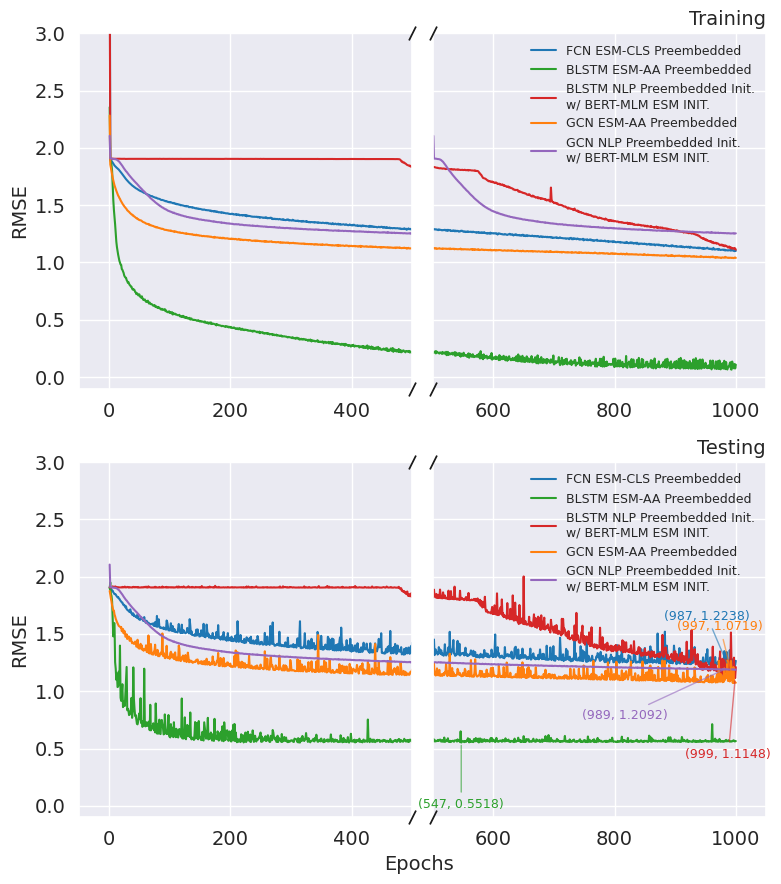

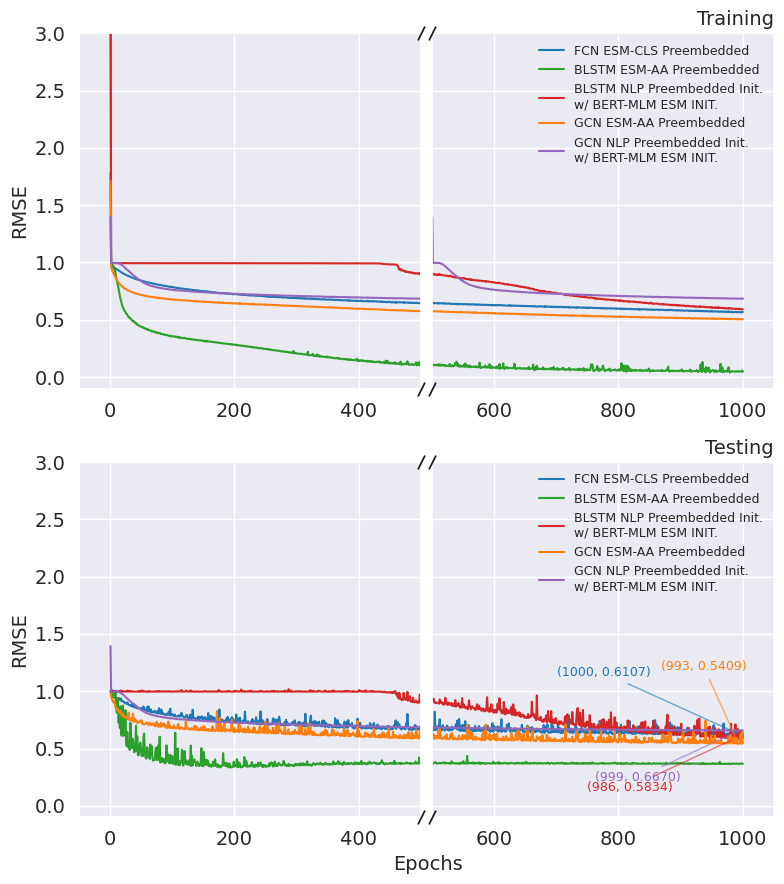

In [6]:
fcn_esm_cls_preembedded = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-12-04_18-51/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
blstm_esm_aa_preembedded = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-05/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
blstm_nlp_preembedded = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-binding-2024-12-05_04-05/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
gcn_esm_aa_preembedded = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-01/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
gcn_nlp_preembedded = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-binding-2024-12-05_09-14/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/preembedded.binding"
coords = {
    "FCN ESM-CLS Preembedded": (-15, 40),
    "BLSTM ESM-AA Preembedded": (0, -40),
    "BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.T": (-5,-50),
    "GCN ESM-AA Preembedded": (-10,45),
    "GCN NLP Preembedded Init. w/ BERT-MLM ESM INIT.T": (-75,-30)
}
print("Binding:")
plot_comparative_split_preembedded_log_file(fcn_esm_cls_preembedded, blstm_esm_aa_preembedded, blstm_nlp_preembedded, gcn_esm_aa_preembedded, gcn_nlp_preembedded, coords, f"{comparison_file}.model_comp_split.pdf")

fcn_esm_cls_preembedded = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-12-04_17-28/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
blstm_esm_aa_preembedded = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_01-06/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
blstm_nlp_preembedded = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-expression-2024-12-05_04-06/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
gcn_esm_aa_preembedded = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_00-48/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
gcn_nlp_preembedded = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-expression-2024-12-05_09-13/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/preembedded.expression"
coords = {
    "FCN ESM-CLS Preembedded": (-100,50),
    "BLSTM ESM-AA Preembedded": (0,-25),
    "BLSTM NLP Preembedded Init. w/ BERT-MLM ESM INIT.T": (-75,-30),
    "GCN ESM-AA Preembedded": (-25,60),
    "GCN NLP Preembedded Init. w/ BERT-MLM ESM INIT.T": (-75,-30)
}
print("\nExpression")
plot_comparative_split_preembedded_log_file(fcn_esm_cls_preembedded, blstm_esm_aa_preembedded, blstm_nlp_preembedded, gcn_esm_aa_preembedded, gcn_nlp_preembedded, coords, f"{comparison_file}.model_comp_split.pdf")